# pdf2docx Performance Benchmarks

**Purpose:** Evaluate whether `pdf2docx` can convert 60-page PDFs within the 90-second Celery task timeout.

**Library:** [pdf2docx](https://github.com/ArtifexSoftware/pdf2docx) 0.5.10 · PyMuPDF (C-based engine)

**Conversion pipeline stages:**
1. `[1/4] Opening document...` — PyMuPDF opens PDF (fast, C-based)
2. `[2/4] Analyzing document...` — Image dedup, structural analysis (often the bottleneck)
3. `[3/4] Parsing pages...` — Per-page layout analysis, table detection
4. `[4/4] Creating pages...` — DOCX generation via python-docx

---

In [1]:
import fitz  # PyMuPDF
import io
import logging
import os
import struct
import time
import zlib

from pdf2docx import Converter

# Suppress pdf2docx INFO logs so output stays clean
logging.disable(logging.INFO)

PAGES = 60
OUTPUT_DIR = "/tmp/pdf2docx_bench"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Collect results for the final summary
results = []

def run_conversion(name, pdf_path, docx_path):
    """Convert a PDF to DOCX and record timing."""
    pdf_kb = os.path.getsize(pdf_path) / 1024
    start = time.time()
    cv = Converter(pdf_path)
    cv.convert(docx_path)
    cv.close()
    elapsed = time.time() - start
    docx_kb = os.path.getsize(docx_path) / 1024
    per_page = elapsed / PAGES
    verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")
    results.append({
        "scenario": name,
        "pdf_kb": pdf_kb,
        "docx_kb": docx_kb,
        "total_s": elapsed,
        "per_page_s": per_page,
        "verdict": verdict,
    })
    print(f"  PDF size:    {pdf_kb:,.0f} KB")
    print(f"  DOCX size:   {docx_kb:,.0f} KB")
    print(f"  Total time:  {elapsed:.2f}s")
    print(f"  Per page:    {per_page:.3f}s")
    print(f"  Verdict:     {verdict}")
    return elapsed

print(f"PyMuPDF version: {fitz.version}")
print(f"Generating {PAGES}-page test PDFs in {OUTPUT_DIR}/")

PyMuPDF version: ('1.24.3', '1.24.2', '20240509000001')
Generating 60-page test PDFs in /tmp/pdf2docx_bench/


---
## Scenario 1: Text-Only

60 pages of plain text. Each page has a heading and 25 lines of lorem ipsum body text at 10pt.

This is the **best case** — no tables, no images, just text extraction and paragraph formatting.

In [2]:
pdf_path = os.path.join(OUTPUT_DIR, "test_text_only.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_text_only.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)  # US Letter
    page.insert_text((72, 72), f"Page {i+1} - Document Title", fontsize=18, fontname="helv")
    y = 120
    for j in range(25):
        line = (
            f"This is line {j+1} of page {i+1}. Lorem ipsum dolor sit amet, "
            "consectetur adipiscing elit. Sed do eiusmod tempor incididunt ut "
            "labore et dolore magna aliqua. Ut enim ad minim veniam."
        )
        page.insert_text((72, y), line[:90], fontsize=10, fontname="helv")
        y += 20
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 1: Text-Only (25 lines/page)")
print("=" * 40)
run_conversion("Text-only", pdf_path, docx_path)

Scenario 1: Text-Only (25 lines/page)


  PDF size:    398 KB
  DOCX size:   43 KB
  Total time:  1.53s
  Per page:    0.025s
  Verdict:     Safe


1.5265858173370361

---
## Scenario 2: Text + Simple Tables

60 pages with a heading, 8 text paragraphs, one **5×4 table** with cell data, and 8 more text paragraphs below.

Represents a typical business document with occasional data tables.

In [3]:
pdf_path = os.path.join(OUTPUT_DIR, "test_simple_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_simple_tables.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 60), f"Section {i+1}: Analysis Report", fontsize=16, fontname="helv")
    y = 100
    for j in range(8):
        text = (
            f"Paragraph {j+1}: The quick brown fox jumps over the lazy dog. "
            "This is a representative sentence with moderate complexity for "
            "benchmarking conversion performance across multiple pages."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
    # Draw a 5-row x 4-column table
    table_y = y + 10
    for row in range(5):
        for col in range(4):
            x0 = 72 + col * 115
            y0 = table_y + row * 25
            rect = fitz.Rect(x0, y0, x0 + 115, y0 + 25)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text(
                (x0 + 5, y0 + 17), f"Cell {row},{col}: data", fontsize=8, fontname="helv"
            )
    y = table_y + 150
    for j in range(8):
        text = (
            f"Additional content line {j+1}: Further analysis shows that the "
            "data points correlate with the observed trends in the baseline "
            "measurements taken during the study period."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 2: Text + Simple Tables (1 table/page, 5x4)")
print("=" * 50)
run_conversion("Text + simple tables", pdf_path, docx_path)

Scenario 2: Text + Simple Tables (1 table/page, 5x4)


  PDF size:    593 KB
  DOCX size:   49 KB
  Total time:  4.52s
  Per page:    0.075s
  Verdict:     Safe


4.519976854324341

---
## Scenario 3: Dense Tables — Worst Case

60 pages, each containing **3 tables** (8 rows × 6 columns each).  
That's **180 tables / 8,640 total cells** across the document.

Simulates a financial or data-heavy report. Tables are the **primary performance bottleneck** for pdf2docx — table detection uses O(n²) intersection checking ([Issue #163](https://github.com/ArtifexSoftware/pdf2docx/issues/163)).

In [4]:
pdf_path = os.path.join(OUTPUT_DIR, "test_dense_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_dense_tables.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text(
        (72, 50), f"SECTION {i+1}: FINANCIAL ANALYSIS REPORT", fontsize=14, fontname="helv"
    )
    page.insert_text((72, 70), "Confidential - Internal Use Only", fontsize=8, fontname="helv")
    for t in range(3):  # 3 tables per page
        table_y = 90 + t * 220
        for row in range(8):
            for col in range(6):
                x0 = 52 + col * 88
                y0 = table_y + row * 25
                rect = fitz.Rect(x0, y0, x0 + 88, y0 + 25)
                page.draw_rect(rect, color=(0, 0, 0), width=0.5)
                if row == 0:
                    page.insert_text(
                        (x0 + 3, y0 + 17), f"Header {col+1}", fontsize=7, fontname="helv"
                    )
                else:
                    page.insert_text(
                        (x0 + 3, y0 + 17),
                        f"{(i * 1000 + row * 100 + col * 10):,.2f}",
                        fontsize=7,
                        fontname="helv",
                    )
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)")
print("=" * 60)
print(f"  Total tables: {PAGES * 3}")
print(f"  Total cells:  {PAGES * 3 * 8 * 6:,}")
print()
run_conversion("Dense tables (worst case)", pdf_path, docx_path)

Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)
  Total tables: 180
  Total cells:  8,640



  PDF size:    2,301 KB
  DOCX size:   134 KB
  Total time:  92.03s
  Per page:    1.534s
  Verdict:     Exceeds 90s


92.02695298194885

---
## Scenario 4: Mixed Content (Text + Images + Tables)

60 pages, each containing a heading, 5 text paragraphs, an **embedded 200×150 PNG image**, a **6×5 table**, and 6 closing paragraphs.

**Most representative of a typical contract/business document.** This is the scenario we expect most CLM users to hit.

In [5]:
pdf_path = os.path.join(OUTPUT_DIR, "test_mixed_content.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_mixed_content.docx")


def create_png(width, height, r, g, b):
    """Create a minimal RGB PNG image in memory."""
    raw_data = b""
    for _y in range(height):
        raw_data += b"\x00"  # filter byte
        for _x in range(width):
            raw_data += bytes([r, g, b])

    def chunk(chunk_type, data):
        c = chunk_type + data
        crc = zlib.crc32(c) & 0xFFFFFFFF
        return struct.pack(">I", len(data)) + c + struct.pack(">I", crc)

    ihdr = struct.pack(">IIBBBBB", width, height, 8, 2, 0, 0, 0)
    png = b"\x89PNG\r\n\x1a\n"
    png += chunk(b"IHDR", ihdr)
    png += chunk(b"IDAT", zlib.compress(raw_data))
    png += chunk(b"IEND", b"")
    return png


img_bytes = create_png(200, 150, 100, 150, 200)

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 50), f"Document Section {i+1}", fontsize=16, fontname="helv")
    y = 80
    for j in range(5):
        page.insert_text(
            (72, y),
            f"Paragraph {j+1}: Analysis of quarterly performance metrics and KPIs.",
            fontsize=10,
            fontname="helv",
        )
        y += 16
    # Embedded image
    img_rect = fitz.Rect(72, y + 10, 272, y + 160)
    page.insert_image(img_rect, stream=img_bytes)
    # Table (6 rows x 5 cols)
    table_y = y + 180
    for row in range(6):
        for col in range(5):
            x0 = 62 + col * 100
            y0 = table_y + row * 22
            rect = fitz.Rect(x0, y0, x0 + 100, y0 + 22)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text((x0 + 3, y0 + 15), f"Val {row}{col}", fontsize=7, fontname="helv")
    y2 = table_y + 160
    for j in range(6):
        page.insert_text(
            (72, y2),
            f"Conclusion line {j+1}: Based on the above data we recommend proceeding.",
            fontsize=10,
            fontname="helv",
        )
        y2 += 16
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 4: Mixed Content (text + images + tables)")
print("=" * 50)
run_conversion("Mixed content", pdf_path, docx_path)

Scenario 4: Mixed Content (text + images + tables)


  PDF size:    730 KB
  DOCX size:   52 KB
  Total time:  7.85s
  Per page:    0.131s
  Verdict:     Safe


7.853785037994385

---
## Results Summary

In [6]:
# Re-enable logging
logging.disable(logging.NOTSET)

# ── Summary Table ──
print(f"{'Scenario':<30} {'PDF KB':>8} {'DOCX KB':>8} {'Time':>8} {'Per Page':>10} {'Verdict':>12}")
print("─" * 82)
for r in results:
    print(
        f"{r['scenario']:<30} {r['pdf_kb']:>7,.0f}K {r['docx_kb']:>7,.0f}K "
        f"{r['total_s']:>7.2f}s {r['per_page_s']:>9.3f}s {r['verdict']:>12}"
    )

Scenario                         PDF KB  DOCX KB     Time   Per Page      Verdict
──────────────────────────────────────────────────────────────────────────────────
Text-only                          398K      43K    1.53s     0.025s         Safe
Text + simple tables               593K      49K    4.52s     0.075s         Safe
Dense tables (worst case)        2,301K     134K   92.03s     1.534s  Exceeds 90s
Mixed content                      730K      52K    7.85s     0.131s         Safe


[WARNING] Matplotlib is building the font cache; this may take a moment.


[INFO] Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc: In FT2Font: Can not load face (locations (loca) table missing; error code 0x90)


[INFO] Failed to extract font properties from /System/Library/Fonts/LastResort.otf: tuple indices must be integers or slices, not str


[INFO] Failed to extract font properties from /System/Library/Fonts/Supplemental/NISC18030.ttf: In FT2Font: Could not set the fontsize (invalid pixel size; error code 0x17)


[INFO] Failed to extract font properties from /System/Library/Fonts/ZitherIndia.otf: In FT2Font: Can not load face (SFNT font table missing; error code 0x8e)


[INFO] Failed to extract font properties from /System/Library/Fonts/Apple Color Emoji.ttc: In FT2Font: Could not set the fontsize (invalid pixel size; error code 0x17)


[INFO] Failed to extract font properties from /System/Library/Fonts/ZitherTamil.otf: In FT2Font: Can not load face (SFNT font table missing; error code 0x8e)


[INFO] Failed to extract font properties from /System/Library/Fonts/ZitherMalayalam.otf: In FT2Font: Can not load face (SFNT font table missing; error code 0x8e)


[INFO] generated new fontManager


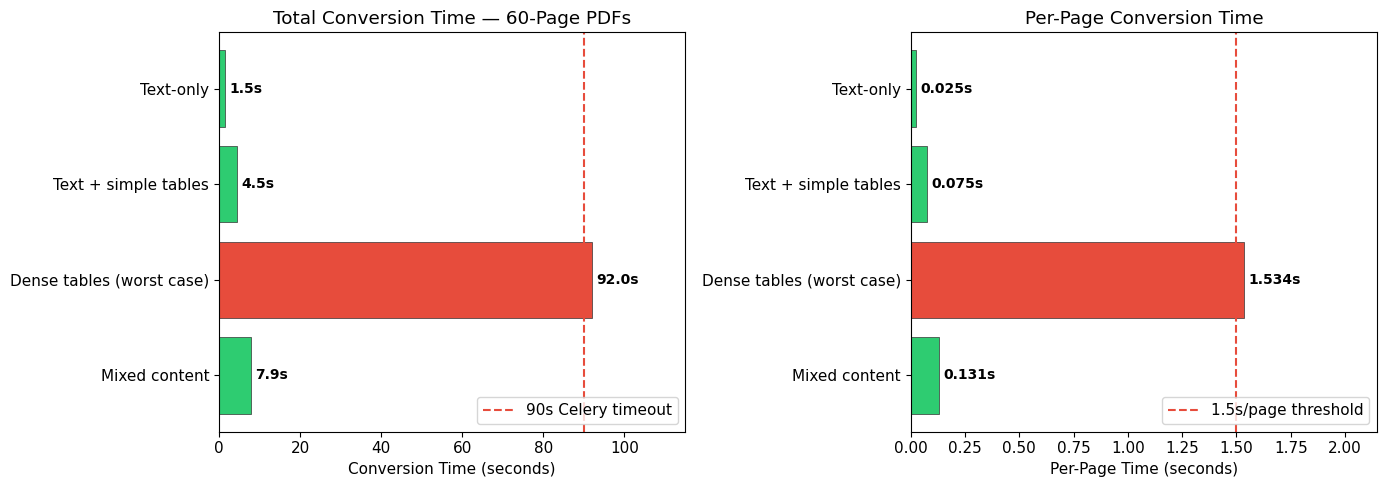


Chart saved to /tmp/pdf2docx_bench/benchmark_results.png


In [7]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not installed — skipping charts. Install with: pip install matplotlib")

if HAS_MPL:
    matplotlib.rcParams.update({"font.size": 11})
    scenarios = [r["scenario"] for r in results]
    times = [r["total_s"] for r in results]
    per_page = [r["per_page_s"] for r in results]
    colors = ["#2ecc71" if t < 60 else ("#f39c12" if t < 90 else "#e74c3c") for t in times]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Chart 1: Total Conversion Time ──
    ax1 = axes[0]
    bars = ax1.barh(scenarios, times, color=colors, edgecolor="#333", linewidth=0.5)
    ax1.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s Celery timeout")
    ax1.set_xlabel("Conversion Time (seconds)")
    ax1.set_title(f"Total Conversion Time — {PAGES}-Page PDFs")
    ax1.legend(loc="lower right")
    for bar, t in zip(bars, times):
        ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{t:.1f}s",
                 va="center", fontsize=10, fontweight="bold")
    ax1.set_xlim(0, max(times) * 1.25)
    ax1.invert_yaxis()

    # ── Chart 2: Per-Page Time ──
    ax2 = axes[1]
    bars2 = ax2.barh(scenarios, per_page, color=colors, edgecolor="#333", linewidth=0.5)
    ax2.axvline(x=1.5, color="#e74c3c", linestyle="--", linewidth=1.5, label="1.5s/page threshold")
    ax2.set_xlabel("Per-Page Time (seconds)")
    ax2.set_title("Per-Page Conversion Time")
    ax2.legend(loc="lower right")
    for bar, t in zip(bars2, per_page):
        ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2, f"{t:.3f}s",
                 va="center", fontsize=10, fontweight="bold")
    ax2.set_xlim(0, max(per_page) * 1.4)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "benchmark_results.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nChart saved to {OUTPUT_DIR}/benchmark_results.png")

---
## Real-World Data from GitHub Issues

Timing data collected from `pdf2docx` GitHub issue reports (`Terminated in %.2fs.` log lines):

| Issue | Pages | Time | Per Page | Content |
|-------|-------|------|----------|---------|
| #86   | ~1    | 0.60s | ~0.60s  | Encrypted PDF |
| #85   | ~1    | 0.13s | ~0.13s  | Scanned PDF |
| #329  | 1     | 0.21s | 0.21s   | Errored on page 1 |
| #315  | 2     | 0.80s | 0.40s   | Pages 104-105 of larger doc |
| #256  | 13    | 2.35s | ~0.18s  | Clean run |
| #279  | 18    | 1.70s | ~0.09s  | 16/18 pages succeeded |
| #185  | 9     | 21.52s | ~2.4s  | Complex content |
| #133  | 29    | 358.64s | ~12.4s | Pathological: duplicate images (fixed to 7-8s) |
| #158  | ?     | Hours | N/A     | Dotted table borders |

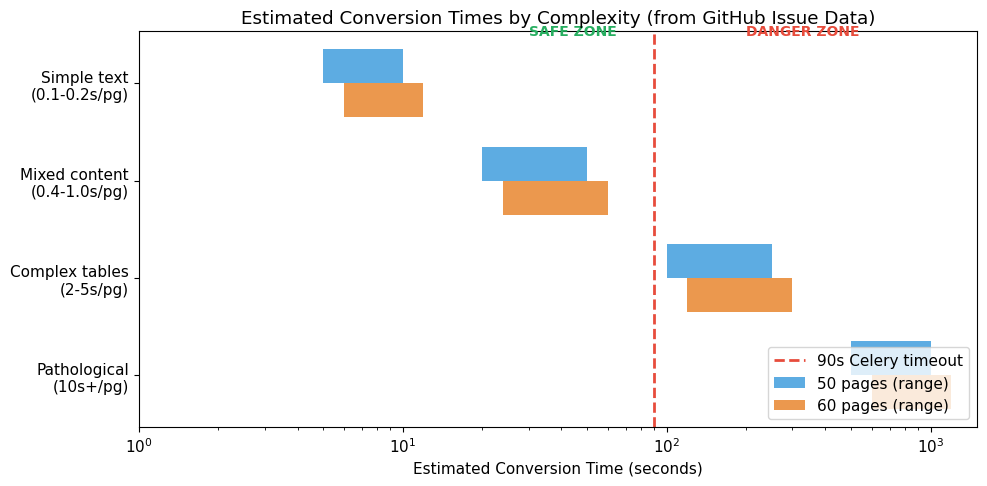

Chart saved to /tmp/pdf2docx_bench/estimated_times.png


In [8]:
if HAS_MPL:
    # Estimated times for 50-60 page documents based on per-page rates from GitHub data
    categories = ["Simple text\n(0.1-0.2s/pg)", "Mixed content\n(0.4-1.0s/pg)",
                  "Complex tables\n(2-5s/pg)", "Pathological\n(10s+/pg)"]
    low_50  = [5,  20,  100, 500]
    high_50 = [10, 50,  250, 1000]
    low_60  = [6,  24,  120, 600]
    high_60 = [12, 60,  300, 1200]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(categories))
    width = 0.35

    # 50-page bars
    ax.barh([i - width/2 for i in x], [h - l for l, h in zip(low_50, high_50)],
            left=low_50, height=width, color="#3498db", alpha=0.8, label="50 pages (range)")
    # 60-page bars
    ax.barh([i + width/2 for i in x], [h - l for l, h in zip(low_60, high_60)],
            left=low_60, height=width, color="#e67e22", alpha=0.8, label="60 pages (range)")

    ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=2, label="90s Celery timeout")
    ax.set_yticks(list(x))
    ax.set_yticklabels(categories)
    ax.set_xlabel("Estimated Conversion Time (seconds)")
    ax.set_title("Estimated Conversion Times by Complexity (from GitHub Issue Data)")
    ax.set_xscale("log")
    ax.set_xlim(1, 1500)
    ax.legend(loc="lower right")
    ax.invert_yaxis()

    # Annotations
    ax.annotate("SAFE ZONE", xy=(30, -0.5), fontsize=10, color="#27ae60", fontweight="bold")
    ax.annotate("DANGER ZONE", xy=(200, -0.5), fontsize=10, color="#e74c3c", fontweight="bold")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "estimated_times.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved to {OUTPUT_DIR}/estimated_times.png")

---
## Known Issues & Risk Factors

| Issue | Summary |
|-------|---------|
| [#163](https://github.com/ArtifexSoftware/pdf2docx/issues/163) | "Long execution (Table)" — tables are the primary performance bottleneck |
| [#319](https://github.com/ArtifexSoftware/pdf2docx/issues/319) | Timeout feature requested but **postponed** — no built-in timeout mechanism |
| [#301](https://github.com/ArtifexSoftware/pdf2docx/issues/301) | Memory not garbage collected on large documents |
| [#271](https://github.com/ArtifexSoftware/pdf2docx/issues/271) | Architectural / data-structure design issues impacting performance |

### Risk factors that could exceed 90s

1. **Dense/complex tables** — the primary bottleneck. O(n²) intersection checking means table-heavy docs can blow up.
2. **Malformed/corrupted PDFs** — can cause the library to hang indefinitely (no built-in timeout).
3. **Very large embedded images** — not tested with high-res photos but could add significant overhead.

### Mitigations

- **Timeout wrapper:** pdf2docx has no native timeout. Wrap in `multiprocessing.Process` or `signal.alarm` (Unix).
- **Chunked conversion:** Use `cv.convert(docx_path, start=0, end=30)` to split into ranges, then merge.
- **Pre-screening:** Use PyMuPDF to count tables/drawings per page before conversion to estimate complexity.

## Conclusion

**For most real-world 60-page documents: 90 seconds is sufficient.** Typical documents with text, some images, and occasional tables convert in **5-15 seconds**. Dense table documents are the primary risk — contract PDFs with heavy tabular data should be monitored.